# RL Agent Training Comparison: base vs adjustment-degree shaping

Сравнивает варианты обучения одного RL edit-агента на **старом датасете**
(`raw_graphs_1000.pkl` + LC-seed маршруты). Отличие — в наборе cost-компонентов
и в adjustment-degree reward-shaping:

| Вариант | Cost-компоненты | Adjustment shaping |
|---|---|---|
| **base**      | RTT + connectivity (no ATT) | — выкл |
| **adj**       | RTT + connectivity (no ATT) | target = 0.2, W = 1 |
| **conn_adj**  | connectivity only (no ATT, no RTT) | target = 0.2, W = 1 |

**Adjustment degree** = alignment-несхожесть маршрута с его seed-версией
(0 = идентичен seed, 1 = полностью переписан). Цель target=0.2 штрафует
`W·|adj − 0.2|` на каждом шаге → агент поощряется переписывать каждый маршрут
≈на 20%: не оставлять как seed (adj=0 → штраф) и не уходить далеко (adj→1 → штраф).

**Adjustment mode = `paper`.** Используется paper-метрика (Holliday) на основе
LCS F-measure с theta-коррекцией асимметрии длин — она (а) литературно-стандартна
и сравнима с опубликованными числами, (б) корректно обрабатывает изменение длины
маршрута при trim/extend (в отличие от `current`, нормирующего по max-длине грубее).

**Реализация.** Adjustment shaping добавлен в `train_lc_improvement_cfg_ppo` как
**отдельный аддитивный терм** к reward'у (не внутри constraint-penalty):
`reward = prev_cost − (base_cost + W·|adj − 0.2|)`, reference = seed-сеть. Терм
активен только при `adjustment_degree_weight > 0`, поэтому base-вариант и всё
прежнее поведение — без изменений.

In [1]:
import os
# Set before importing torch if you need a specific GPU:
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from hydra import compose, initialize_config_dir
from IPython.display import display

from eval_lib.context import (ROOT_DIR, CFG_DIR, RAW_GRAPHS_PATH,
                              LC_RESULTS_DIR, MODEL_OUTPUTS_DIR,
                              EDIT_MODEL_WEIGHTS_DIR)
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from connectpt.routes_generator import utils as lrnu
from connectpt.routes_generator.improvement_learning import (
    load_raw_graphs_and_lc_routes, make_improvement_batch,
    rollout_lc_improvement, train_lc_improvement_cfg)
from connectpt.routes_generator.bee_colony import get_adjustment_degrees
from connectpt.routes_generator.torch_utils import get_batch_tensor_from_routes
from eval_lib.results_io import save_table
from eval_lib import plots as _plots

pd.set_option("display.max_columns", None)
print(f"Config dir: {CFG_DIR}")
print(f"Graphs:     {RAW_GRAPHS_PATH}")
print(f"LC routes:  {LC_RESULTS_DIR}")

Config dir: D:\PythonProjects\connectpt\connectpt\routes_generator\cfg
Graphs:     D:\PythonProjects\connectpt\datasets\raw_graphs_1000.pkl
LC routes:  D:\PythonProjects\connectpt\datasets\nx_heuristic_results_10r_len12


## Конфигурация

`N_ITERATIONS` — главный knob длительности (variable). Все варианты используют
**один и тот же** train/val split и seed — отличие только в cost-компонентах и
adjustment-shaping. `VARIANT_SPECS` задаёт список прогонов.

In [ ]:
# --- Главный knob: число PPO-итераций на каждый вариант ---
N_ITERATIONS = 100                 # variable; YAML default = 200.

# --- Adjustment-degree shaping ---
ADJ_TARGET = 0.2       # целевая степень переписывания маршрута
ADJ_WEIGHT = 1.0       # вес penalty-терма W
ADJ_MODE = "paper"     # paper (LCS F-measure, Holliday) -- выбран как лучший
ADJ_GAP = 0.1          # используется только режимом 'current'; paper игнорирует

# --- Размерности задачи / обучения (как в lc_improvement_training) ---
MIN_ROUTE_LEN = 2
MAX_ROUTE_LEN = 12
TARGET_N_ROUTES = 10
MAX_ROUTE_EDIT_STEPS = MAX_ROUTE_LEN
BATCH_SIZE = 32
TRAIN_FRACTION = 0.9
SPLIT_SEED = 0
MAX_TRIM_ACTIONS_PER_ROUTE = 1

EXPERIMENT_NAME = "rl_adjustment_comparison"

# Каждый вариант: (tag, disabled_components, adjustment_weight, color).
# disabled=["demand"]            -> RTT + connectivity (no ATT)
# disabled=["demand", "route"]  -> connectivity only
VARIANT_SPECS = [
    {"tag": "base",     "disabled": ["demand"],          "adj_weight": 0.0,        "color": "tab:blue"},
    {"tag": "adj",      "disabled": ["demand"],          "adj_weight": ADJ_WEIGHT, "color": "tab:red"},
    {"tag": "conn_adj", "disabled": ["demand", "route"], "adj_weight": ADJ_WEIGHT, "color": "tab:green"},
]
VARIANT_COLORS = {s["tag"]: s["color"] for s in VARIANT_SPECS}

print(f"N_ITERATIONS: {N_ITERATIONS}  (per variant)")
print(f"Adjustment:   target={ADJ_TARGET}, weight={ADJ_WEIGHT}, mode={ADJ_MODE}")
for s in VARIANT_SPECS:
    print(f"  - {s['tag']:9s} disabled={s['disabled']}  adj_weight={s['adj_weight']}")

N_ITERATIONS: 100  (per variant)
Adjustment:   target=0.2, weight=1.0, mode=paper
  - base      disabled=['demand']  adj_weight=0.0
  - adj       disabled=['demand']  adj_weight=1.0
  - conn_adj  disabled=['demand', 'route']  adj_weight=1.0


## Загрузка старого датасета + общий split

In [3]:
graphs, seed_routes = load_raw_graphs_and_lc_routes(
    RAW_GRAPHS_PATH, LC_RESULTS_DIR)
N_GRAPHS = len(graphs)
print(f"Graphs: {N_GRAPHS}, seed_routes: {tuple(seed_routes.shape)}")

# Один общий детерминированный split для всех вариантов (честное сравнение).
_perm = torch.randperm(N_GRAPHS, generator=torch.Generator().manual_seed(SPLIT_SEED))
_n_train = int(TRAIN_FRACTION * N_GRAPHS)
TRAIN_INDICES = _perm[:_n_train].clone()
VAL_INDICES = _perm[_n_train:].clone()
print(f"Train graphs: {len(TRAIN_INDICES)}  |  Val graphs: {len(VAL_INDICES)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Graphs: 1000, seed_routes: (1000, 10, 12)
Train graphs: 900  |  Val graphs: 100
Device: cpu


## Helper: обучить один вариант

`train_variant` строит **свежие** model + cost_obj из cfg, отключает заданные
cost-компоненты, задаёт adjustment-knobs через cfg-оверрайды и запускает
PPO-обучение на общем split.

In [4]:
def train_variant(tag, disabled_components, adjustment_weight):
    """Train one RL variant. adjustment_weight=0 -> base; >0 -> adj-shaped."""
    run_name = f"{EXPERIMENT_NAME}_{tag}"
    overrides = [
        "model=bestsofar_feb2023_trim",
        "model.route_generator.kwargs.serial_halting=True",
        f"++run_name={run_name}",
        "++experiment.logdir=null",
        f"++adjustment_degree_weight={float(adjustment_weight)}",
        f"++adjustment_degree_target={float(ADJ_TARGET)}",
        f"++adjustment_degree_gap={float(ADJ_GAP)}",
        f"++adjustment_degree_mode={ADJ_MODE}",
    ]
    with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
        cfg = compose(config_name="ppo_50nodes.yaml", overrides=overrides)

    dev, resolved_run_name, _, cost_obj, model = \
        lrnu.process_standard_experiment_cfg(cfg, run_name_prefix="improvement_")
    cost_obj.ignore_stops_oob = True
    cost_obj.set_enabled_components(
        disabled_components=disabled_components or None)

    best_model_path = EDIT_MODEL_WEIGHTS_DIR / f"{resolved_run_name}.pt"
    print(f"\n{'='*60}\nTraining variant '{tag}'  "
          f"(adjustment_weight={adjustment_weight})")
    print(f"Enabled cost components: {list(cost_obj.enabled_component_names)}")
    print(f"{'='*60}")

    train_result = train_lc_improvement_cfg(
        model=model, cost_obj=cost_obj, graphs=graphs, seed_routes=seed_routes,
        device=dev, cfg=cfg, output_dir=MODEL_OUTPUTS_DIR,
        run_name=resolved_run_name, train_fraction=TRAIN_FRACTION,
        batch_size=BATCH_SIZE, min_route_len=MIN_ROUTE_LEN,
        max_route_len=MAX_ROUTE_LEN, seed=SPLIT_SEED,
        max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
        max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE,
        target_n_routes=TARGET_N_ROUTES,
        train_indices=TRAIN_INDICES, val_indices=VAL_INDICES,
        best_model_path=best_model_path,
        n_iterations=N_ITERATIONS,
    )
    hist_df = pd.DataFrame(train_result["history"])
    hist_df["variant"] = tag
    return {
        "tag": tag,
        "history": hist_df,
        "best_model_path": best_model_path,
        "cfg": cfg,
        "cost_obj": cost_obj,
        "disabled": list(disabled_components),
        "adj_weight": adjustment_weight,
        "enabled_components": list(cost_obj.enabled_component_names),
    }


print("train_variant ready")

train_variant ready


## Запуск всех вариантов

По одному полному PPO-прогону на вариант (`N_ITERATIONS` итераций каждый).

In [5]:
VARIANTS = {}
for spec in VARIANT_SPECS:
    VARIANTS[spec["tag"]] = train_variant(
        spec["tag"], spec["disabled"], spec["adj_weight"])

# Сохранить истории на диск (переживают рестарт kernel'а).
combined_hist = pd.concat(
    [VARIANTS[s["tag"]]["history"] for s in VARIANT_SPECS], ignore_index=True)
save_table(combined_hist, f"{EXPERIMENT_NAME}_history")
print("\nDone. Histories saved.")


Training variant 'base'  (adjustment_weight=0.0)
Enabled cost components: ['route', 'connectivity']


cfg ppo improvement:   1%|          | 1/100 [02:11<3:36:37, 131.28s/it, reward=-0.013, delta=-0.023, ratio=1.003, clip=6.47%]

cfg_ppo_iter=001 reward=-0.0126 train_delta=-0.0233 val_delta=nan ratio=1.003 clip=6.47% actions=ext:477 trim_s:378 trim_e:351 halt:1407 avg_steps=1.86 eval=False


cfg ppo improvement:   2%|▏         | 2/100 [04:24<3:36:44, 132.70s/it, reward=-0.013, delta=-0.023, ratio=0.998, clip=11.69%]

cfg_ppo_iter=002 reward=-0.0130 train_delta=-0.0230 val_delta=nan ratio=0.998 clip=11.69% actions=ext:448 trim_s:348 trim_e:337 halt:1519 avg_steps=1.73 eval=False


...

cfg_ppo_iter=098 reward=0.0381 train_delta=0.1083 val_delta=1.4466 ratio=1.003 clip=3.71% actions=ext:1073 trim_s:123 trim_e:222 halt:766 avg_steps=2.84 eval=False


cfg ppo improvement:  99%|█████████▉| 99/100 [4:46:55<02:45, 165.57s/it, reward=0.032, delta=0.083, ratio=1.001, clip=1.43%]

cfg_ppo_iter=099 reward=0.0317 train_delta=0.0830 val_delta=1.4466 ratio=1.001 clip=1.43% actions=ext:909 trim_s:113 trim_e:194 halt:677 avg_steps=2.69 eval=False


cfg ppo improvement: 100%|██████████| 100/100 [4:51:29<00:00, 174.90s/it, reward=0.036, delta=0.089, ratio=0.996, clip=1.98%]

cfg_ppo_iter=100 reward=0.0364 train_delta=0.0893 val_delta=1.4529 ratio=0.996 clip=1.98% actions=ext:1071 trim_s:128 trim_e:230 halt:892 avg_steps=2.59 eval=True
[results] table (300 rows) -> D:\PythonProjects\connectpt\artifacts\results\rl_adjustment_comparison_history.csv

Done. Histories saved.


## Кривые обучения всех вариантов

Headline-панели на одних осях. demand отключён везде, поэтому per-component
панели показывают RTT и connectivity (для `conn_adj` RTT-delta показывает, что
стало с route-time, хотя он не оптимизировался).

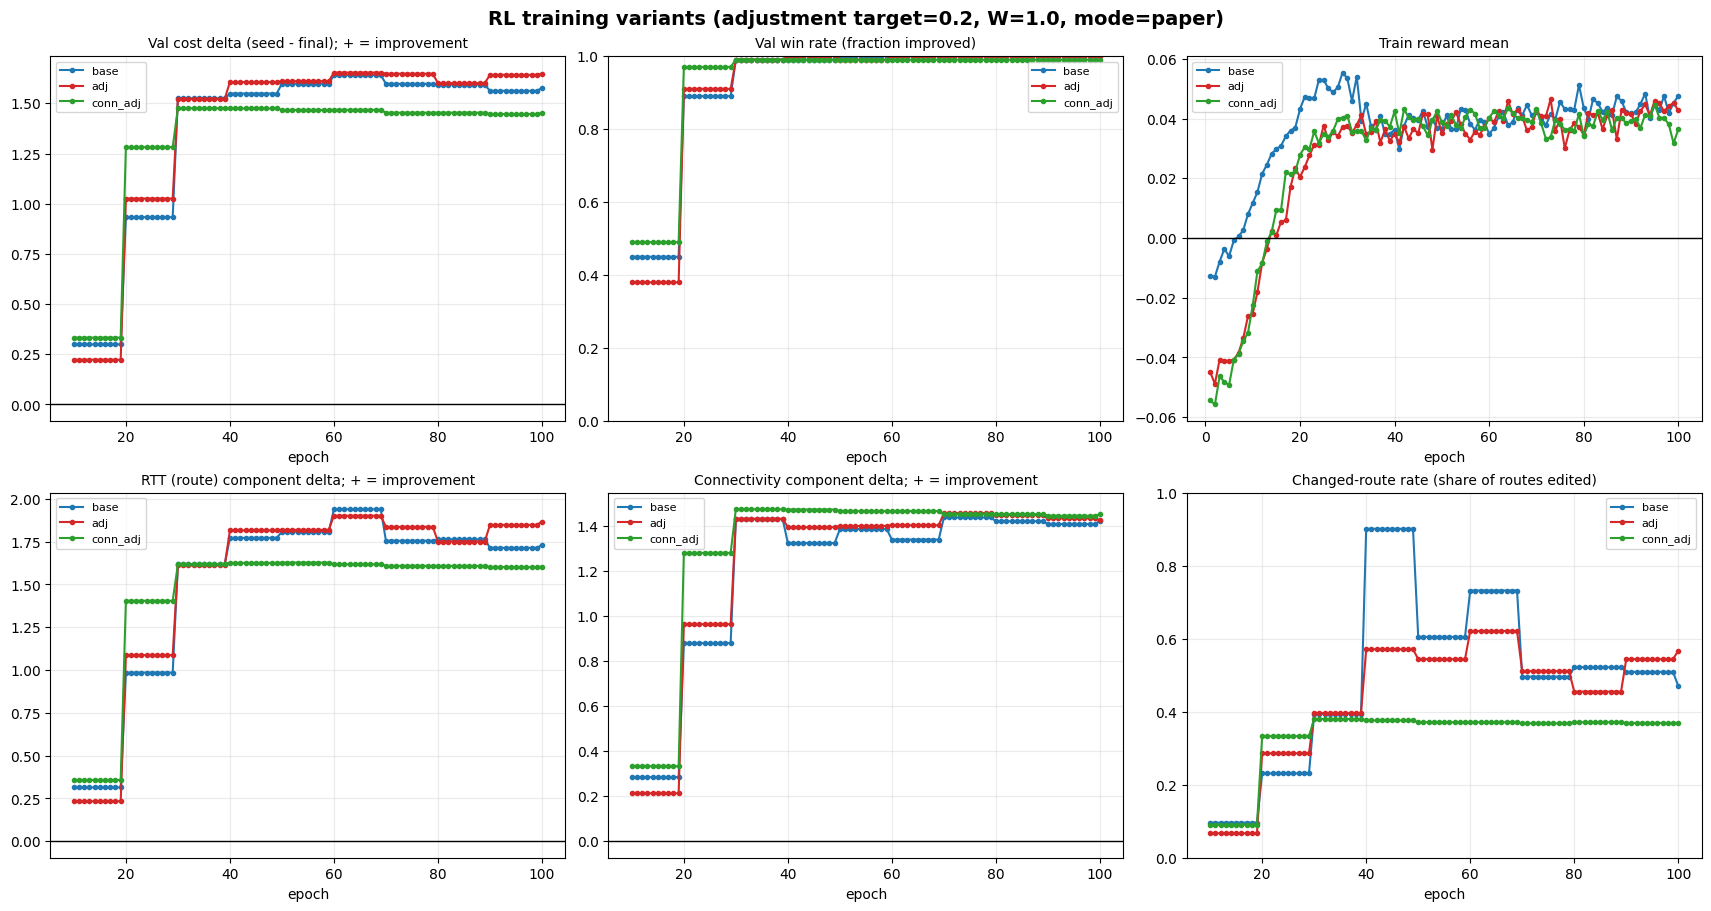

In [6]:
def _series(df, col):
    if col not in df.columns:
        return None, None
    y = pd.to_numeric(df[col], errors="coerce")
    return df["epoch"], y


def _plot_all(ax, col, title, ylim=None, hline=None):
    for tag, res in VARIANTS.items():
        x, y = _series(res["history"], col)
        if y is not None and y.notna().any():
            ax.plot(x, y, marker="o", ms=3, color=VARIANT_COLORS[tag],
                    label=tag)
    if hline is not None:
        ax.axhline(hline, color="black", linewidth=1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("epoch")
    if ylim:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)


fig, axes = plt.subplots(2, 3, figsize=(17, 9), constrained_layout=True)
_plot_all(axes[0, 0], "val_delta", "Val cost delta (seed - final); + = improvement", hline=0)
_plot_all(axes[0, 1], "val_win_rate", "Val win rate (fraction improved)", ylim=(0, 1))
_plot_all(axes[0, 2], "train_reward_mean", "Train reward mean", hline=0)
_plot_all(axes[1, 0], "val_component_delta_route", "RTT (route) component delta; + = improvement", hline=0)
_plot_all(axes[1, 1], "val_component_delta_connectivity", "Connectivity component delta; + = improvement", hline=0)
_plot_all(axes[1, 2], "val_changed_route_rate", "Changed-route rate (share of routes edited)", ylim=(0, 1))

fig.suptitle(
    f"RL training variants (adjustment target={ADJ_TARGET}, W={ADJ_WEIGHT}, mode={ADJ_MODE})",
    fontsize=14, fontweight="bold")
plt.show()
plt.close(fig)

## Эффект регуляризации: достигнутый adjustment degree

Прогоняем обученные политики (greedy) на val-графах, считаем adjustment degree
(paper-метрика) финальной сети относительно seed (per-route, усреднён по сети).
Ожидание: **adj и conn_adj удерживают adjustment около 0.2**, **base** свободен.

In [7]:
EVAL_CHUNK = 16   # графов за раз (память rollout)


def eval_adjustment_and_cost(res, indices):
    """Greedy-rollout the trained variant; return per-graph (adj_degree, cost)."""
    cfg = res["cfg"]
    cost_obj = res["cost_obj"]
    model = lrnu.build_model_from_cfg(cfg.model, cfg.experiment)
    model.load_state_dict(torch.load(res["best_model_path"], map_location=device))
    model.to(device).eval()

    adj_all, cost_all = [], []
    idx_list = indices.tolist()
    for start in range(0, len(idx_list), EVAL_CHUNK):
        batch_idx = torch.tensor(idx_list[start:start + EVAL_CHUNK])
        graph_batch, route_batch = make_improvement_batch(
            graphs, seed_routes, batch_idx, device, training=False,
            target_n_routes=TARGET_N_ROUTES)
        cost_weights = cost_obj.get_weights(device)
        with torch.no_grad():
            out = rollout_lc_improvement(
                model, cost_obj, graph_batch, route_batch,
                MIN_ROUTE_LEN, MAX_ROUTE_LEN, greedy=True,
                cost_weights=cost_weights,
                max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
                max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE)
        final_state = out[0]
        improved = get_batch_tensor_from_routes(
            final_state.routes, device,
            max_route_len=route_batch.shape[-1]).to(device)
        seed_full = route_batch.to(device)
        n_routes = min(improved.shape[1], seed_full.shape[1])
        width = min(improved.shape[-1], seed_full.shape[-1])
        adj = get_adjustment_degrees(
            improved[:, :n_routes, :width], seed_full[:, :n_routes, :width],
            cost_obj.symmetric_routes, gap=ADJ_GAP, mode=ADJ_MODE)
        adj_all.append(adj.mean(dim=1).cpu())
        cost_all.append(cost_obj(final_state).cost.detach().cpu())
    return torch.cat(adj_all).numpy(), torch.cat(cost_all).numpy()


EVAL_RESULTS = {}
for tag, res in VARIANTS.items():
    adj_arr, cost_arr = eval_adjustment_and_cost(res, VAL_INDICES)
    EVAL_RESULTS[tag] = {"adj": adj_arr, "cost": cost_arr}
    print(f"{tag:9s}  adj_degree mean={adj_arr.mean():.3f}  "
          f"(target={ADJ_TARGET})   final_cost mean={cost_arr.mean():.4f}")

base       adj_degree mean=0.337  (target=0.2)   final_cost mean=0.8574
adj        adj_degree mean=0.280  (target=0.2)   final_cost mean=0.8446
conn_adj   adj_degree mean=0.212  (target=0.2)   final_cost mean=0.2229


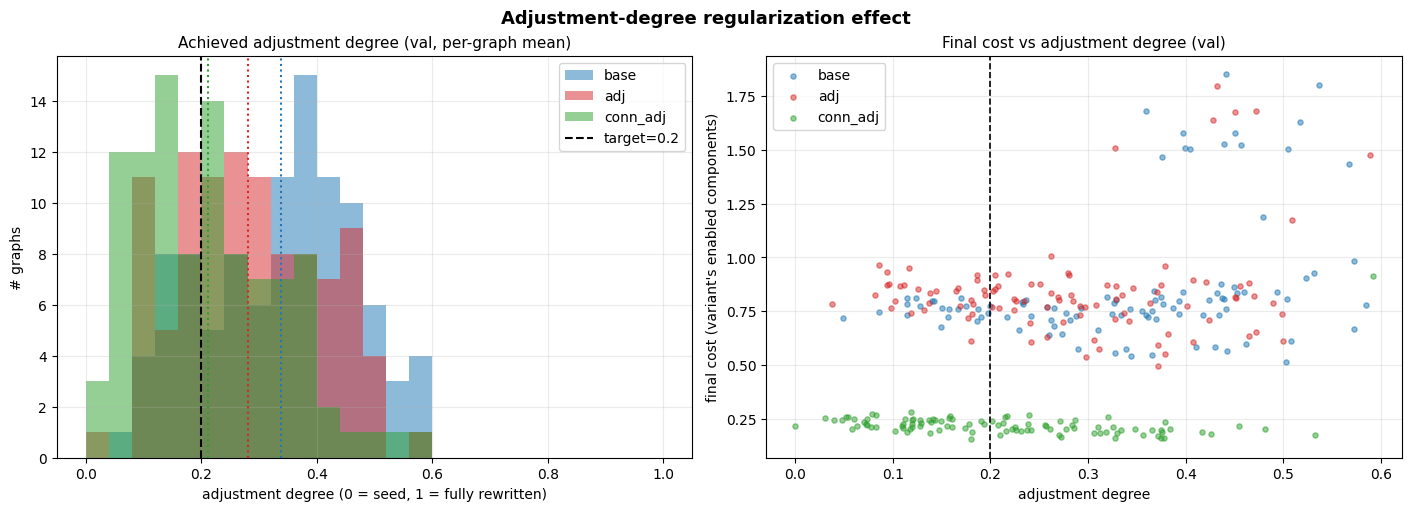

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
_bins = np.linspace(0, 1, 26)

# [0] adjustment-degree distributions
ax = axes[0]
for tag in VARIANTS:
    arr = EVAL_RESULTS[tag]["adj"]
    ax.hist(arr, bins=_bins, alpha=0.5, color=VARIANT_COLORS[tag], label=tag)
    ax.axvline(arr.mean(), color=VARIANT_COLORS[tag], linestyle=":", linewidth=1.5)
ax.axvline(ADJ_TARGET, color="black", linestyle="--", linewidth=1.5,
           label=f"target={ADJ_TARGET}")
ax.set_title("Achieved adjustment degree (val, per-graph mean)", fontsize=11)
ax.set_xlabel("adjustment degree (0 = seed, 1 = fully rewritten)")
ax.set_ylabel("# graphs")
ax.legend()
ax.grid(alpha=0.25)

# [1] cost vs adjustment scatter -- the trade-off (cost in each variant's
# own enabled-component objective)
ax = axes[1]
for tag in VARIANTS:
    ax.scatter(EVAL_RESULTS[tag]["adj"], EVAL_RESULTS[tag]["cost"], s=14,
               alpha=0.5, color=VARIANT_COLORS[tag], label=tag)
ax.axvline(ADJ_TARGET, color="black", linestyle="--", linewidth=1.2)
ax.set_title("Final cost vs adjustment degree (val)", fontsize=11)
ax.set_xlabel("adjustment degree")
ax.set_ylabel("final cost (variant's enabled components)")
ax.legend()
ax.grid(alpha=0.25)

fig.suptitle("Adjustment-degree regularization effect", fontsize=13,
             fontweight="bold")
plt.show()
plt.close(fig)

## Сводная таблица

In [9]:
def _last_finite(df, col):
    if col not in df.columns:
        return float("nan")
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    return float(s.iloc[-1]) if len(s) else float("nan")


rows = []
for tag, res in VARIANTS.items():
    h = res["history"]
    adj_arr = EVAL_RESULTS[tag]["adj"]
    cost_arr = EVAL_RESULTS[tag]["cost"]
    rows.append({
        "variant": tag,
        "enabled_components": "+".join(res["enabled_components"]),
        "adjustment_weight": res["adj_weight"],
        "final_val_delta": _last_finite(h, "val_delta"),
        "final_val_win_rate": _last_finite(h, "val_win_rate"),
        "final_route_delta": _last_finite(h, "val_component_delta_route"),
        "final_conn_delta": _last_finite(h, "val_component_delta_connectivity"),
        "val_adj_degree_mean": float(np.mean(adj_arr)),
        "val_adj_degree_std": float(np.std(adj_arr)),
        "val_cost_mean": float(np.mean(cost_arr)),
        "val_changed_route_rate": _last_finite(h, "val_changed_route_rate"),
    })

summary_df = pd.DataFrame(rows).round(4)
display(summary_df)
save_table(summary_df, f"{EXPERIMENT_NAME}_summary")
print(f"Saved -> artifacts/results/{EXPERIMENT_NAME}_summary.csv")

,variant,enabled_components,adjustment_weight,final_val_delta,final_val_win_rate,final_route_delta,final_conn_delta,val_adj_degree_mean,val_adj_degree_std,val_cost_mean,val_changed_route_rate
0,base,route+connectivity,0.0,1.5769,1.00,1.7305,1.4232,0.3373,0.1290,0.8574,0.470
1,adj,route+connectivity,1.0,1.6472,1.00,1.8675,1.4269,0.2804,0.1230,0.8446,0.567
2,conn_adj,connectivity,1.0,1.4529,0.99,1.6048,1.4529,0.2122,0.1207,0.2229,0.369


[results] table (3 rows) -> D:\PythonProjects\connectpt\artifacts\results\rl_adjustment_comparison_summary.csv
Saved -> artifacts/results/rl_adjustment_comparison_summary.csv


## Детальный разбор на одном val-графе

Берём один граф из валидации, прогоняем каждую обученную политику (greedy) и
сравниваем **ATT / RTT / connectivity / adjustment** (+ cost) в таблице и на
bar-фигуре. ATT/RTT/MC считаются под общим full-objective, поэтому сопоставимы
между вариантами независимо от того, какие компоненты были включены в обучении.
`seed` — исходная LC-сеть (adjustment = 0 по определению).

In [10]:
from connectpt.routes_generator.transit_time_estimator import RouteGenBatchState
from torch_geometric.data import Batch
from connectpt.routes_generator.utils import get_eval_cfg

# Один граф из val для детального разбора.
FOCUS_GRAPH_IDX = int(VAL_INDICES[0])
focus_graph = graphs[FOCUS_GRAPH_IDX]

# Общий full-objective (все 3 компонента) -> сопоставимые ATT/RTT/MC у всех
# вариантов (ATT/RTT/MC -- абсолютные метрики, не зависят от enabled-маски).
_focus_cfg = get_eval_cfg(
    str(CFG_DIR), "eval_model_mumford",
    {"dataset_name": "tensor", "n_routes": TARGET_N_ROUTES,
     "min_route_len": MIN_ROUTE_LEN, "max_route_len": MAX_ROUTE_LEN,
     "run_name": "adj_focus_eval"})
_focus_cfg.batch_size = 1
_, _, _, FOCUS_COST_OBJ, _ = lrnu.process_standard_experiment_cfg(
    _focus_cfg, run_name_prefix="adj_focus_", weights_required=False)
FOCUS_COST_OBJ.ignore_stops_oob = True


def _scalar(v):
    return float(v.detach().reshape(-1)[0].cpu()) if torch.is_tensor(v) else float(v)


def eval_routes_on_focus(routes_tensor):
    """Absolute ATT/RTT/connectivity/cost of a route set on the focus graph."""
    gb = Batch.from_data_list([focus_graph.clone()]).to(device)
    rt = routes_tensor.to(device)
    if rt.ndim == 2:
        rt = rt[None]
    state = RouteGenBatchState(
        gb, FOCUS_COST_OBJ, TARGET_N_ROUTES, MIN_ROUTE_LEN, MAX_ROUTE_LEN)
    state.add_new_routes(rt)
    r = FOCUS_COST_OBJ(state)
    m = r.get_metrics()
    return {"ATT": _scalar(m.get("ATT", float("nan"))),
            "RTT": _scalar(m.get("RTT", float("nan"))),
            "connectivity": _scalar(m.get("median_connectivity", float("nan"))),
            "cost": _scalar(r.cost)}


def improve_on_focus(res):
    """Greedy-rollout a trained variant on the focus graph; return its routes,
    achieved adjustment degree vs seed, and the seed route set."""
    cfg = res["cfg"]
    cost_obj = res["cost_obj"]
    model = lrnu.build_model_from_cfg(cfg.model, cfg.experiment)
    model.load_state_dict(torch.load(res["best_model_path"], map_location=device))
    model.to(device).eval()
    bidx = torch.tensor([FOCUS_GRAPH_IDX])
    gb, rb = make_improvement_batch(
        graphs, seed_routes, bidx, device, training=False,
        target_n_routes=TARGET_N_ROUTES)
    with torch.no_grad():
        out = rollout_lc_improvement(
            model, cost_obj, gb, rb, MIN_ROUTE_LEN, MAX_ROUTE_LEN,
            greedy=True, cost_weights=cost_obj.get_weights(device),
            max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
            max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE)
    improved = get_batch_tensor_from_routes(
        out[0].routes, device, max_route_len=rb.shape[-1])
    seed_full = rb.to(device)
    nr = min(improved.shape[1], seed_full.shape[1])
    w = min(improved.shape[-1], seed_full.shape[-1])
    adj = get_adjustment_degrees(
        improved[:, :nr, :w], seed_full[:, :nr, :w],
        cost_obj.symmetric_routes, gap=ADJ_GAP, mode=ADJ_MODE).mean().item()
    return improved[0].cpu(), float(adj), seed_full[0].cpu()


# seed (одинаков для всех вариантов) + результат каждого варианта
FOCUS_ROUTES = {}
focus_rows = []
_seed_added = False
for tag, res in VARIANTS.items():
    improved, adj, seed_focus = improve_on_focus(res)
    if not _seed_added:
        FOCUS_ROUTES["seed"] = seed_focus
        focus_rows.append({"variant": "seed", **eval_routes_on_focus(seed_focus),
                           "adjustment": 0.0})
        _seed_added = True
    FOCUS_ROUTES[tag] = improved
    focus_rows.append({"variant": tag, **eval_routes_on_focus(improved),
                       "adjustment": adj})

print(f"Focus graph #{FOCUS_GRAPH_IDX}: computed routes/metrics for "
      f"{[r['variant'] for r in focus_rows]}")

Focus graph #884: computed routes/metrics for ['seed', 'base', 'adj', 'conn_adj']


Focus graph index (val): 884


,variant,ATT,RTT,connectivity,adjustment,cost
0,seed,29.5077,1014.7039,24.1008,0.0000,2.0635
1,base,33.2735,886.7017,26.7384,0.1501,0.6698
2,adj,32.3060,985.4588,26.0279,0.1382,0.7124
3,conn_adj,32.2248,982.4577,25.9798,0.1382,0.7101


[results] table (4 rows) -> D:\PythonProjects\connectpt\artifacts\results\rl_adjustment_comparison_focus_graph.csv


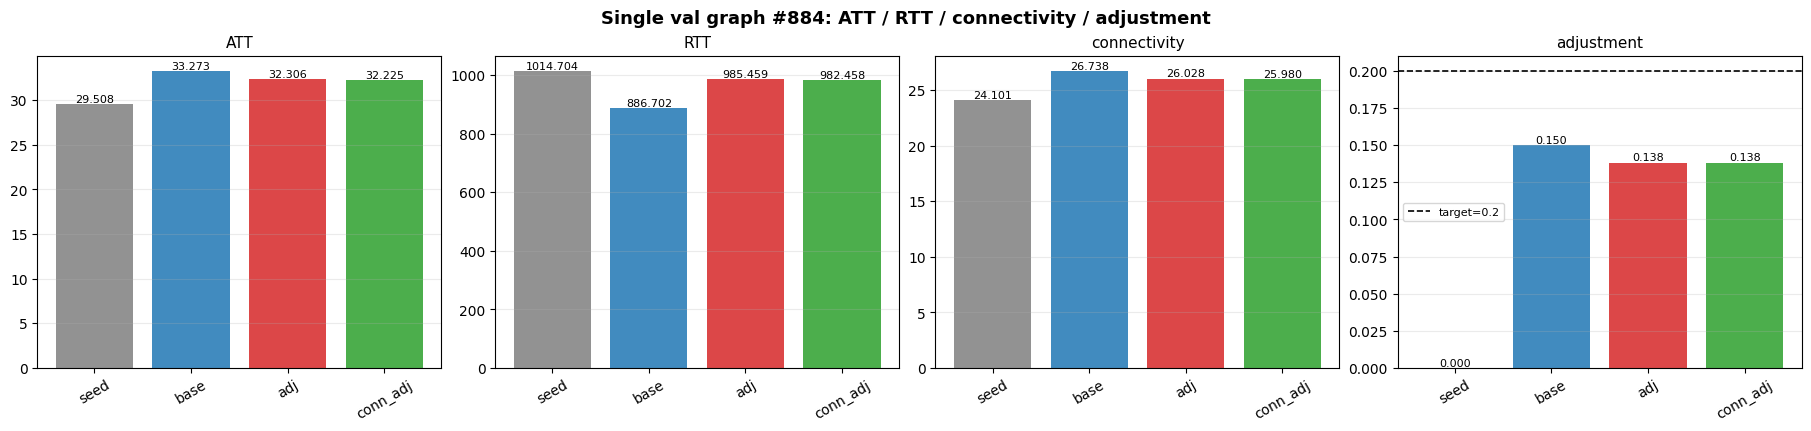

In [11]:
# Сводная таблица по одному графу + bar-фигура: ATT / RTT / connectivity / adjustment
focus_df = pd.DataFrame(focus_rows)[
    ["variant", "ATT", "RTT", "connectivity", "adjustment", "cost"]].round(4)
print(f"Focus graph index (val): {FOCUS_GRAPH_IDX}")
display(focus_df)
save_table(focus_df, f"{EXPERIMENT_NAME}_focus_graph")

_metrics_to_plot = ["ATT", "RTT", "connectivity", "adjustment"]
_order = ["seed"] + [s["tag"] for s in VARIANT_SPECS]
_row_by_variant = {r["variant"]: r for r in focus_rows}
_bar_colors = {"seed": "tab:gray", **VARIANT_COLORS}

fig, axes = plt.subplots(1, len(_metrics_to_plot), figsize=(18, 4.2),
                         constrained_layout=True)
for ax, metric in zip(axes, _metrics_to_plot):
    vals = [_row_by_variant[v][metric] for v in _order]
    colors = [_bar_colors.get(v, "tab:blue") for v in _order]
    bars = ax.bar(_order, vals, color=colors, alpha=0.85)
    if metric == "adjustment":
        ax.axhline(ADJ_TARGET, color="black", linestyle="--", linewidth=1.2,
                   label=f"target={ADJ_TARGET}")
        ax.legend(fontsize=8)
    ax.set_title(metric, fontsize=11)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(alpha=0.25, axis="y")
    for b, val in zip(bars, vals):
        ax.annotate(f"{val:.3f}", (b.get_x() + b.get_width() / 2, val),
                    ha="center", va="bottom", fontsize=8)

fig.suptitle(
    f"Single val graph #{FOCUS_GRAPH_IDX}: ATT / RTT / connectivity / adjustment",
    fontsize=13, fontweight="bold")
plt.show()
plt.close(fig)

## Визуализация маршрутов на одном графе

Карты route-set для seed и каждого варианта на том же val-графе. Дугами
(`with_overlap_curves=True`) отображаются **дублирующиеся / перекрывающиеся
рёбра** — где несколько маршрутов идут по одному и тому же участку.

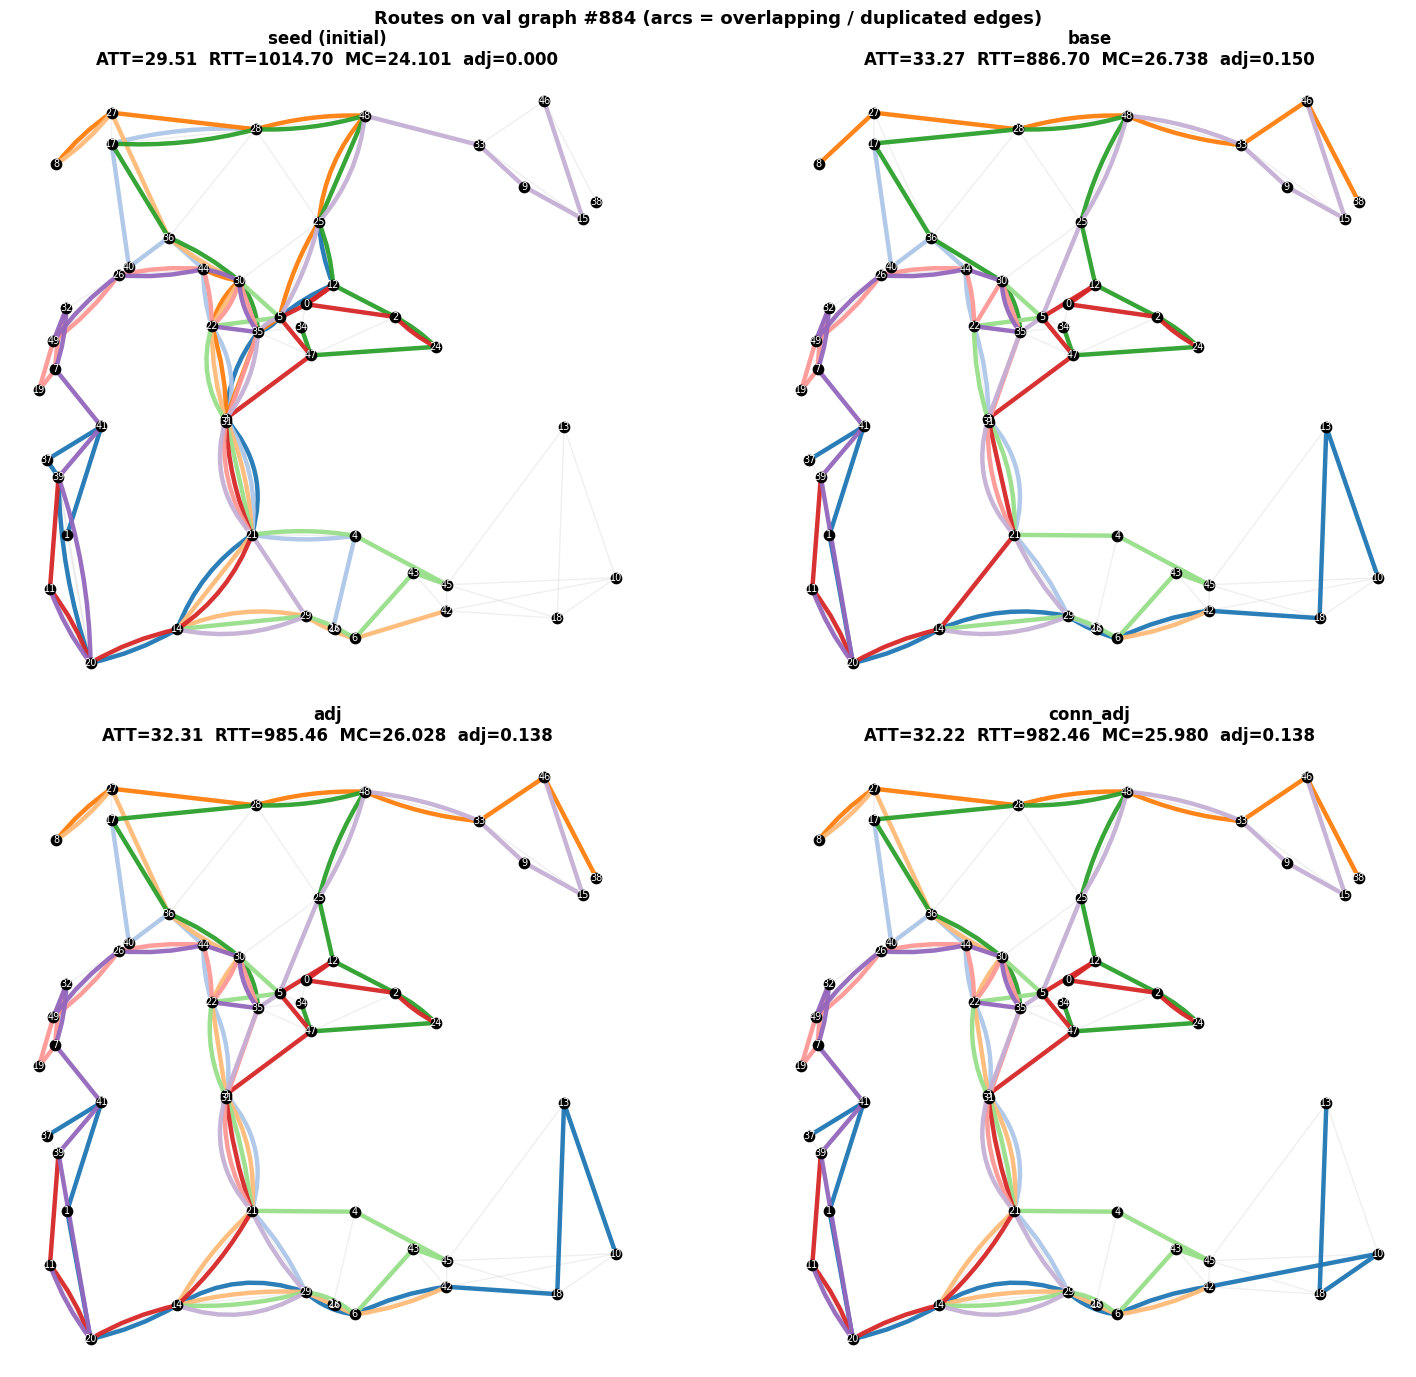

In [12]:
_order = ["seed"] + [s["tag"] for s in VARIANT_SPECS]
_row_by_variant = {r["variant"]: r for r in focus_rows}
_titles = {"seed": "seed (initial)", "base": "base",
           "adj": "adj", "conn_adj": "conn_adj"}

ncols = min(len(_order), 2)
nrows = (len(_order) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(8.0 * ncols, 7.0 * nrows),
                         squeeze=False)
axes = axes.flatten()
for ax, v in zip(axes, _order):
    r = _row_by_variant[v]
    subtitle = (f"ATT={r['ATT']:.2f}  RTT={r['RTT']:.2f}  "
                f"MC={r['connectivity']:.3f}  adj={r['adjustment']:.3f}")
    # with_overlap_curves=True -> дублирующиеся/перекрывающиеся рёбра рисуются дугами
    _plots.plot_plain_route_set(
        ax, FOCUS_ROUTES[v], focus_graph,
        title=_titles.get(v, v), subtitle=subtitle,
        palette="tab20", with_overlap_curves=True)
for ax in axes[len(_order):]:
    ax.axis("off")

fig.suptitle(
    f"Routes on val graph #{FOCUS_GRAPH_IDX} "
    f"(arcs = overlapping / duplicated edges)",
    fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
plt.close(fig)